#                            Titanic Survival
**Goal:** Predict if a passenger survived the Titanic sinking based on their age, sex, ticket class, etc.
**Dataset:** `train.csv` from Kaggle.


In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # For drawing basic graphs
import seaborn as sns    # For drawing pretty graphs

print("Libraries loaded successfully!")


Libraries loaded successfully!


# loading dataset

In [2]:
df=pd.read_csv('train.cvs.csv')
# Look at the first 5 rows to make sure it loaded correctly
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##  Step 2: Feature Selection (Cleaning Data)

Machine Learning algorithms only understand math If we feed them random names or empty spaces, they break
 Before we run our model
 we must use human logic to decide which columns matter

**IMPORTANT (Keep these):**
* `Sex` and `Age`: "Women and children first" was maritime law.
* `Pclass` and `Fare`: Rich passengers in 1st class had cabins closest to the top decks and lifeboats.

**NOT Important(Drop these):**
* `PassengerId`: A random row number assigned by the database. Not useful.
* `Name`: A random string of letters. The algorithm cannot do math on a name.
* `Ticket`: A random alphanumeric code (like A/5 211).
* `Cabin`: Even though knowing their cabin location would be useful, 77% of passengers have a blank space (`NaN`) for their cabin. We cannot learn from an empty column.


In [ ]:
# drop the garbage columns!
df= df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# check the new, clean table
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
# check how many blank spaces (NaN) are in every single column
a=df.isnull().sum()

# see it as a percentage 
b=df.isnull().mean() * 100

# only show columns that actually have missing values
c=df.isnull().sum()[df.isnull().sum() > 0]

# total missing values across the entire DataFrame
d=df.isnull().sum().sum()

print(f"how many blank spaces (NaN) in every single colmn: {a}")

print(f"\n See it as a percentage:  {b}")

print(f"\n Only show columns that actually have missing values: {c}")

print(f"\n  Total missing values across the entire DataFrame: {d}")

how many blank spaces (NaN) in every single colmn: Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

 See it as a percentage:  Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Embarked     0.224467
dtype: float64

 Only show columns that actually have missing values: Age         177
Embarked      2
dtype: int64

  Total missing values across the entire DataFrame: 179


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X=df.drop('Survived', axis=1)
Y=df['Survived']

X_train,X_test,Y_train,Y_test=train_test_split(X,Y, test_size=0.2)

imputer=SimpleImputer(strategy='mean')

#push the "Age" column through the machine, and save it back into the table
X_train['Age'] = imputer.fit_transform(X_train[['Age']])
X_test['Age'] = imputer.fit_transform(X_test[['Age']])

X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
X_test['Sex'] = X_test['Sex'].map({'male': 0, 'female': 1})

# The "translation" code
#translate text into numbers
X_train['Embarked'] = X_train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
X_test['Embarked'] = X_test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})


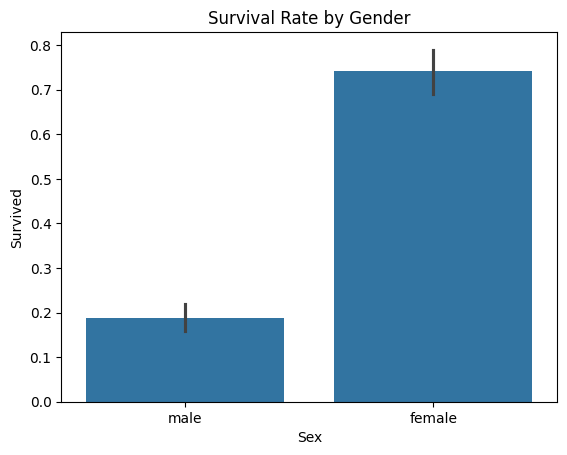

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# let's see who survived based on gender (0 = Male, 1 = Female)
# we plot this using the original 'df' table before we split it so we can see the answers
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.show()



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(random_state=42)

model.fit(X_train,Y_train)

prediction=model.predict(X_test)

accuracy=accuracy_score(Y_test,prediction)

print(f"computer is this much accurate: {accuracy*100:.3f}")